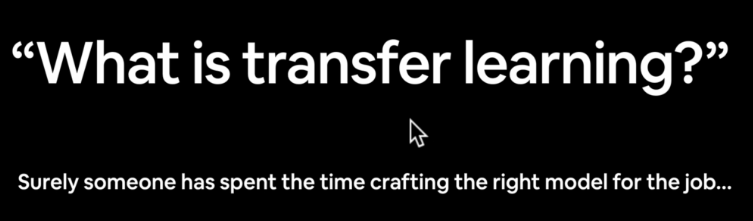

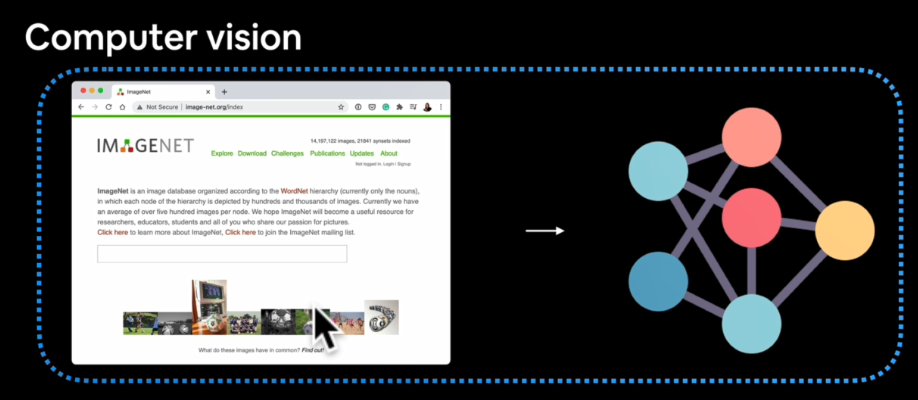

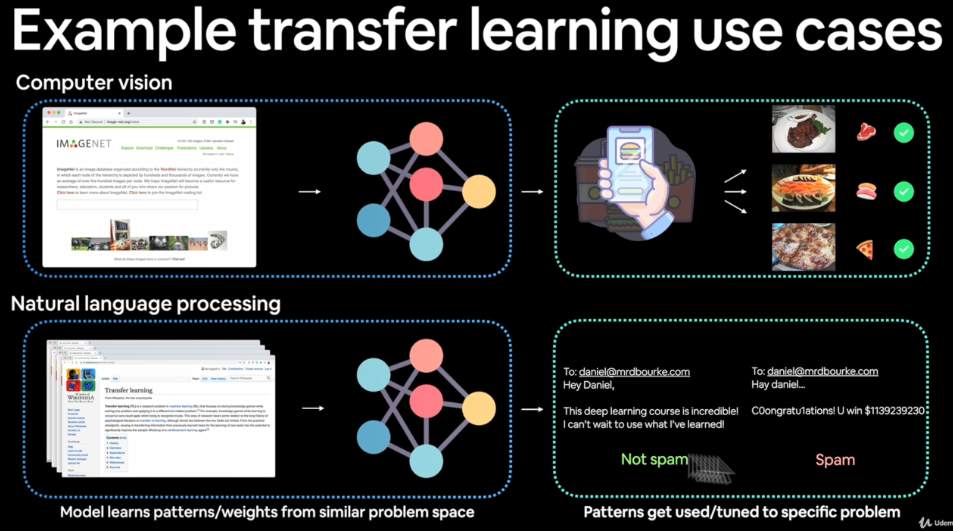

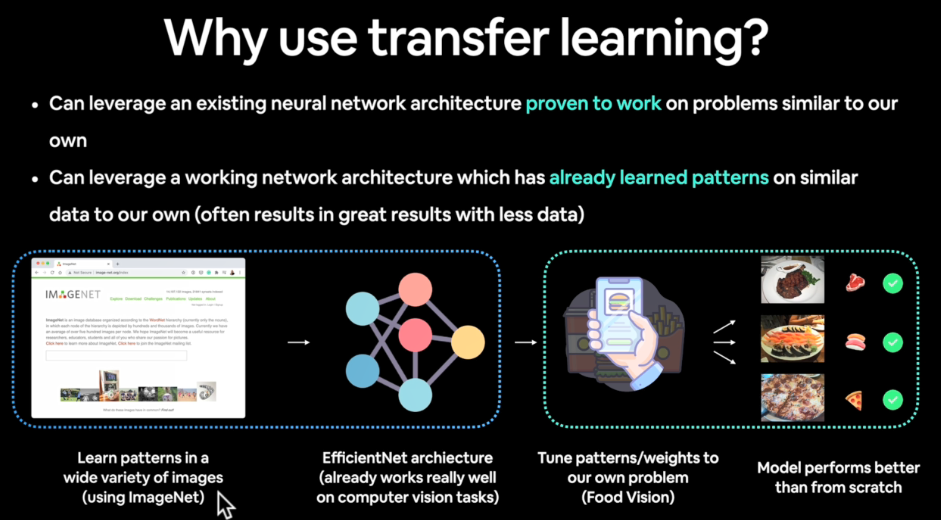

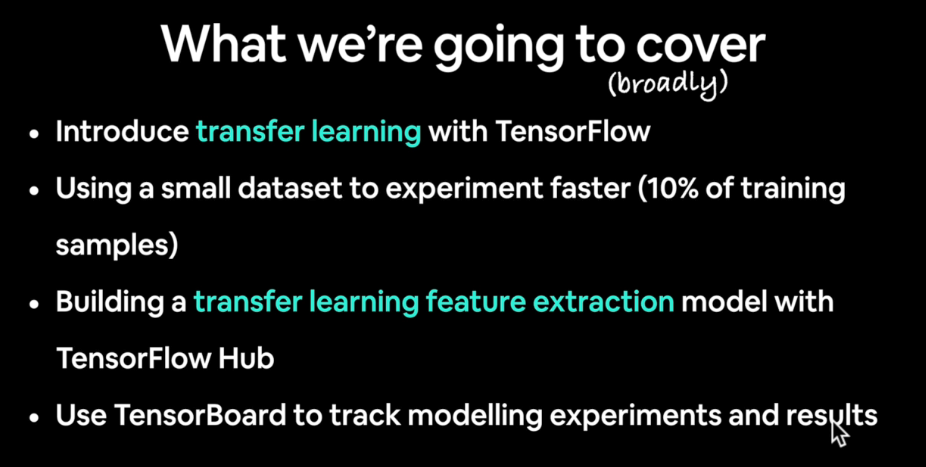

<h1 style="color:red">lec 002:- Downloading and preparing data for our first transfer learning model.mp4</h1>

# Transfer Learning with TensorFlow Part 1: Feature Extraction

Transfer learning is leveraging a working model's existing architecture and learned patterns for our own problem.

There are two main benefits:
1. Can leverage an exitsing neural network architecture proven to work on problems similar to our own.
2. Can leverage a working neural network architecture which has already learned patterns on similar data to our own, then we can adapt those patterns to our own data.

In [1]:
# Are we using a GPU?
!nvidia-smi

Wed Jan 28 19:09:04 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   49C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Downloading and becoming one with the data

In [2]:
# Get data (10% of 10 food classes from Food101) - https://www.kaggle.com/dansbecker/food-101
import zipfile

# Download the data
!wget https://storage.googleapis.com/ztm_tf_course/food_vision/10_food_classes_10_percent.zip

# Unzip the downloaded file
zip_ref = zipfile.ZipFile("10_food_classes_10_percent.zip")
zip_ref.extractall()
zip_ref.close()

--2026-01-28 19:09:05--  https://storage.googleapis.com/ztm_tf_course/food_vision/10_food_classes_10_percent.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 173.194.202.207, 173.194.203.207, 74.125.199.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|173.194.202.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 168546183 (161M) [application/zip]
Saving to: ‘10_food_classes_10_percent.zip’

10_food_classes_10_ 100%[===================>] 160.74M   136MB/s    in 1.2s    

2026-01-28 19:09:06 (136 MB/s) - ‘10_food_classes_10_percent.zip’ saved [168546183/168546183]



In [3]:
# How many images in each folder?
import os

# Walk through 10 percent data directory and list number of files
for dirpath, dirnames, filenames in os.walk("10_food_classes_10_percent"):
  print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'")

There are 2 directories and 0 images in '10_food_classes_10_percent'
There are 10 directories and 0 images in '10_food_classes_10_percent/train'
There are 0 directories and 75 images in '10_food_classes_10_percent/train/grilled_salmon'
There are 0 directories and 75 images in '10_food_classes_10_percent/train/hamburger'
There are 0 directories and 75 images in '10_food_classes_10_percent/train/ramen'
There are 0 directories and 75 images in '10_food_classes_10_percent/train/fried_rice'
There are 0 directories and 75 images in '10_food_classes_10_percent/train/steak'
There are 0 directories and 75 images in '10_food_classes_10_percent/train/chicken_curry'
There are 0 directories and 75 images in '10_food_classes_10_percent/train/ice_cream'
There are 0 directories and 75 images in '10_food_classes_10_percent/train/sushi'
There are 0 directories and 75 images in '10_food_classes_10_percent/train/pizza'
There are 0 directories and 75 images in '10_food_classes_10_percent/train/chicken_wing

## Creating data loaders (preparing the data)

We'll use the `ImageDataGenerator` class to load in our images in batches.

In [4]:
# Setup data inputs
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMAGE_SHAPE = (224,224)
BATCH_SIZE = 32

train_dir = "10_food_classes_10_percent/train/"
test_dir = "10_food_classes_10_percent/test/"

train_datagen = ImageDataGenerator(rescale=1/255.)
test_datagen = ImageDataGenerator(rescale=1/255.)

print("Training images:")
train_data = train_datagen.flow_from_directory(train_dir,
                                               target_size=IMAGE_SHAPE,
                                               batch_size = BATCH_SIZE,
                                               class_mode="categorical")

print("Testing images:")
test_data = test_datagen.flow_from_directory(test_dir,
                                             target_size=IMAGE_SHAPE,
                                             batch_size = BATCH_SIZE,
                                             class_mode="categorical")

Training images:
Found 750 images belonging to 10 classes.
Testing images:
Found 2500 images belonging to 10 classes.


<h1 style="color:red">lec 003:-Introducing Callbacks in TensorFlow and making a callback to track our models.mp4</h1>

## Setting up callbacks (things to run whilst our model trains)

Callbacks are extra functionality you can add to your models to be performed during or after training. Some of the most popular callbacks:

* Tracking experiments with the TensorBoard callback
* Model checkpoint with the ModelCheckpoint callback
* Stopping a model from training (before it trains too long and overfits) with the EarlyStopping callback

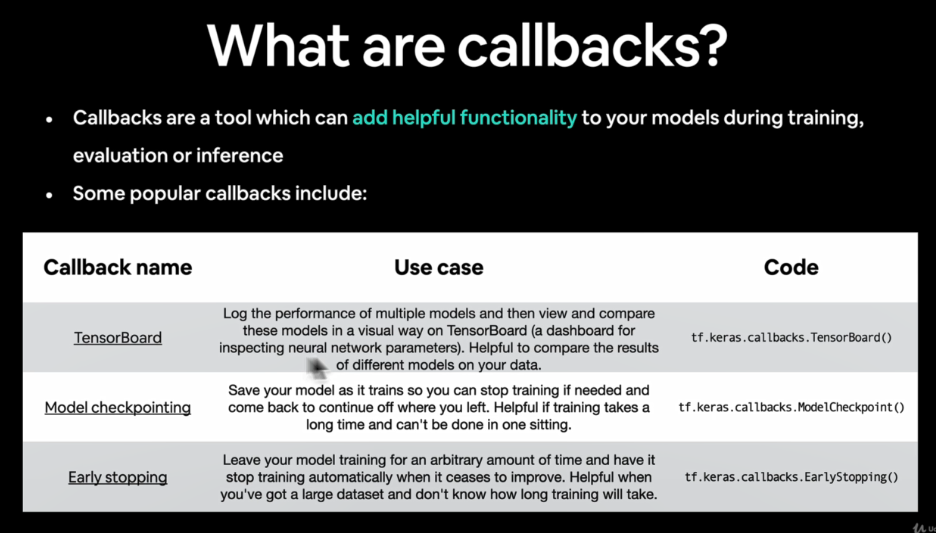

In [5]:
# Create TensorBoard callback (functionized because we need to create a new one for each model)
import datetime
import tensorflow as tf

def create_tensorboard_callback(dir_name, experiment_name):
  log_dir = dir_name + "/" + experiment_name + "/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
  tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir)
  print(f"Saving TensorBoard log files to: {log_dir}")
  return tensorboard_callback

> 🔑**Note:** You can customize the directory where your TensorBoard logs(model training metrics) get saved to whatever you like. The `log_dir` parameter we've created above is only one option.

<h1 style="color:red">lec 004:-Exploring the TensorFlow Hub website for pretrained models.mp4</h1>

## Creating models using TensorFlow Hub

In the past we've used TensorFlow to create our own models layer by layer from scratch.

Now we're going to do a similar process, except the majority of our model's layers are going to come from Tensorflow Hub.

We can access pretrained models on https://www.kaggle.com/models?tfhub-redirect=true

Browsing the TensorFlow Hub page and sorting for image classification, we found the following feature vector model link: https://www.kaggle.com/models/google/efficientnet-v2/tensorFlow2/imagenet1k-b0-feature-vector

<h1 style="color:red">lec 005:-Building and compiling a TensorFlow Hub feature extraction model.mp4</h1>

In [6]:
# Let's compare the following two models
resnet_url = "https://tfhub.dev/google/imagenet/resnet_v2_50/feature_vector/4"
efficientnet_url = "https://www.kaggle.com/models/google/efficientnet-v2/TensorFlow2/imagenet1k-b0-feature-vector/2"


In [7]:
# Import dependencies
import tensorflow as tf
import tensorflow_hub as hub
from tensorflow.keras import layers

In [8]:
# Let's make a create_model() function to create a model form a URL
def create_model(model_url,num_classes=10):
  """
  Takes a TensorFlow Hub URL and creates a Keras Sequential Model with it.

  Args:
    model_url (str): A TensorFlow Hub feature extraction URL.
    num_classes (int): Number of output neurons in the output layer,
      should be equal to number of target classes, default 10.

  Returns:
    An uncompiled Keras Sequential model with model_url as feature extractor
    layer and Dense output layer with num_classes output neurons.
  """
  # Download the pretrained model and save it as a Keras layer
  inputs = tf.keras.Input(shape=IMAGE_SHAPE+(3,))

  feature_extractor_layer = hub.KerasLayer(model_url,
                                           trainable=False, # freeze the already learned patterns
                                           name="feature_extraction_layer")(inputs) # add a

  outputs = layers.Dense(num_classes,activation="softmax",name="output_layer")(feature_extractor_layer)

  # Create our own model
  model = tf.keras.Model(inputs,outputs)

  return model

### Creating and testing ResNet TensorFlow Hub Feature Extraction model

In [9]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.applications.efficientnet import (
    EfficientNetB0,
    preprocess_input
)

IMAGE_SHAPE = (224, 224)

def create_efficientnet_model(num_classes):
    # Base model
    base_model = EfficientNetB0(
        include_top=False,
        weights="imagenet",
        pooling="avg"
    )

    # CRITICAL: freeze BEFORE compile
    base_model.trainable = False

    inputs = tf.keras.Input(shape=IMAGE_SHAPE + (3,))

    # EXACT ImageNet preprocessing
    x = preprocess_input(inputs)

    # Force inference mode for BatchNorm
    x = base_model(x, training=False)

    # Stronger classification head
    x = layers.BatchNormalization()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(
        num_classes,
        activation="softmax",
        name="output_layer"
    )(x)

    model = tf.keras.Model(inputs, outputs)
    return model


In [10]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess

def create_resnet_model(num_classes):
    base_model = ResNet50(
        weights="imagenet",
        include_top=False,
        input_shape=IMAGE_SHAPE + (3,),
        pooling="avg"
    )
    base_model.trainable = False

    inputs = tf.keras.Input(shape=IMAGE_SHAPE + (3,))
    x = resnet_preprocess(inputs)
    x = base_model(x, training=False)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    return tf.keras.Model(inputs, outputs)


In [11]:
resnet_model = create_resnet_model(train_data.num_classes)
efficientnet_model = create_efficientnet_model(train_data.num_classes)


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [12]:
resnet_model.summary()
efficientnet_model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ input_layer_1[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ input_layer_1[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 2048)      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 10)        │     20,490 │ resnet50[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,608,202 (90.06 MB)

 Trainable params: 20,490 (80.04 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 1280)           │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,385,197 (16.73 MB)

 Trainable params: 333,066 (1.27 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

In [13]:
# Compile our resnet model
resnet_model.compile(loss="categorical_crossentropy",
                     optimizer=tf.keras.optimizers.Adam(),
                     metrics=["accuracy"])

In [14]:
# Compile our efficientnet model
efficientnet_model.compile(loss="categorical_crossentropy",
                     optimizer=tf.keras.optimizers.Adam(),
                     metrics=["accuracy"])

<h1 style="color:red">lec 006:-Blowing our previous models out of the water with transfer learning.mp4</h1>

In [15]:
# Let's fit our ResNet model to the data (10 percent of 10 classes)
resnet_history = resnet_model.fit(train_data,
                                  epochs=5,
                                  steps_per_epoch=len(train_data),
                                  validation_data=test_data,
                                  validation_steps=len(test_data),
                                  callbacks=[create_tensorboard_callback(dir_name="tensorflow_hub",
                                                                         experiment_name="resnet50v2")])

Saving TensorBoard log files to: tensorflow_hub/resnet50v2/20260128-190923


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 37s 899ms/step - accuracy: 0.0918 - loss: 2.5164 - val_accuracy: 0.1000 - val_loss: 2.3254
Epoch 2/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 9s 392ms/step - accuracy: 0.1022 - loss: 2.3249 - val_accuracy: 0.1088 - val_loss: 2.3215
Epoch 3/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 9s 382ms/step - accuracy: 0.1303 - loss: 2.3177 - val_accuracy: 0.1132 - val_loss: 2.3088
Epoch 4/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 10s 420ms/step - accuracy: 0.1094 - loss: 2.3170 - val_accuracy: 0.1048 - val_loss: 2.2984
Epoch 5/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 12s 531ms/step - accuracy: 0.1339 - loss: 2.3061 - val_accuracy: 0.1256 - val_loss: 2.3062


### By chatgpt fine  tuning


In [16]:
# import tensorflow as tf
# from tensorflow.keras import layers
# from tensorflow.keras.applications import ResNet50V2
# from tensorflow.keras.applications.resnet_v2 import preprocess_input

# def create_resnet_model(num_classes, image_shape):
#     base_model = ResNet50V2(
#         weights="imagenet",
#         include_top=False,
#         input_shape=image_shape + (3,)
#     )
#     base_model.trainable = False  # Stage 1: feature extractor

#     inputs = tf.keras.Input(shape=image_shape + (3,))
#     x = preprocess_input(inputs)
#     x = base_model(x, training=False)

#     # Strong classifier head
#     x = layers.GlobalAveragePooling2D()(x)
#     x = layers.Dense(256, activation="relu")(x)
#     x = layers.BatchNormalization()(x)
#     x = layers.Dropout(0.5)(x)

#     outputs = layers.Dense(num_classes, activation="softmax")(x)

#     model = tf.keras.Model(inputs, outputs)
#     return model


In [17]:
# model = create_resnet_model(10, IMAGE_SHAPE)

# model.compile(
#     optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
#     loss="categorical_crossentropy",
#     metrics=["accuracy"]
# )


In [18]:
# model_history = model.fit(train_data,
#                           epochs=15,
#                           steps_per_epoch=len(train_data),
#                           validation_data=test_data,
#                           validation_steps=len(test_data),
#                           )

In [19]:
# base_model = model.get_layer("resnet50v2")

# base_model.trainable = True

# # Freeze most of the network
# for layer in base_model.layers[:-30]:
#     layer.trainable = False

# model.compile(
#     optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
#     loss="categorical_crossentropy",
#     metrics=["accuracy"]
# )


In [20]:
# model.fit(
#     train_data,
#     validation_data=test_data,
#     epochs=10
# )


In [21]:
# import tensorflow as tf
# from tensorflow.keras import layers
# from tensorflow.keras.applications import ResNet50V2
# from tensorflow.keras.applications.resnet_v2 import preprocess_input


# def create_resnet_model2(num_classes, image_shape):
#     # Data augmentation (CRITICAL)
#     data_augmentation = tf.keras.Sequential([
#         layers.RandomFlip("horizontal"),
#         layers.RandomRotation(0.15),
#         layers.RandomZoom(0.2),
#         layers.RandomContrast(0.2),
#         layers.RandomBrightness(0.2),
#     ])

#     base_model = ResNet50V2(
#         weights="imagenet",
#         include_top=False,
#         input_shape=image_shape + (3,)
#     )
#     base_model.trainable = False  # stage 1

#     inputs = tf.keras.Input(shape=image_shape + (3,))
#     x = data_augmentation(inputs)
#     x = preprocess_input(x)
#     x = base_model(x, training=False)

#     x = layers.GlobalAveragePooling2D()(x)
#     x = layers.Dense(128, activation="relu")(x)
#     x = layers.BatchNormalization()(x)
#     x = layers.Dropout(0.6)(x)

#     outputs = layers.Dense(num_classes, activation="softmax")(x)

#     model = tf.keras.Model(inputs, outputs)
#     return model


In [22]:
# model2 = create_resnet_model2(train_data.num_classes, IMAGE_SHAPE)

# model2.compile(
#     optimizer=tf.keras.optimizers.Adam(1e-4),
#     loss="categorical_crossentropy",
#     metrics=["accuracy"]
# )


In [23]:
# early_stop = tf.keras.callbacks.EarlyStopping(
#     monitor="val_loss",
#     patience=3,
#     restore_best_weights=True
# )

# model2.fit(
#     train_data,
#     validation_data=test_data,
#     epochs=20,
#     callbacks=[early_stop]
# )


In [24]:
# base_model2 = model2.get_layer("resnet50v2")
# base_model2.trainable = True

# # Freeze MORE layers (important for small datasets)
# for layer in base_model2.layers[:-60]:
#     layer.trainable = False

# model2.compile(
#     optimizer=tf.keras.optimizers.Adam(1e-5),
#     loss="categorical_crossentropy",
#     metrics=["accuracy"]
# )


In [25]:
# model2.fit(
#     train_data,
#     validation_data=test_data,
#     epochs=15,
#     callbacks=[early_stop]
# )


Wow!

That. Is. Incredible. Our transfer learning feature extractor model out performed ALL of the previous models we built by hand... (substantially) and in a quicker training time AND with only 10% of the training examples.

### outside chatgpt

<h1 style="color:red">lec 007:-Plotting the loss curves of our ResNet feature extraction model.mp4</h1>

In [26]:
# Let's create a function to plot our loss curves...
# Tidbit: you could put a function like this into a script called "helper.py" and import it when you need it...
import matplotlib.pyplot as plt

# Plot the validation and training curves
def plot_loss_curves(history):
  """
  Returns separate loss curves for training and validation metrics.

  Args:
    history: TensorFlow model History object

  Returns:
    Plots of training/validation loss and accuracy metrics.
  """
  # this function will fail when in model compilation metrics is something else rather than accuracy
  loss = history.history["loss"]
  val_loss = history.history["val_loss"]

  accuracy = history.history["accuracy"]
  val_accuracy = history.history["val_accuracy"]

  epochs = range(len(history.history["loss"]))

  # Plot loss
  plt.plot(epochs,loss,label = "training_loss")
  plt.plot(epochs,val_loss,label = "val_loss")
  plt.title("Loss")
  plt.xlabel("Epochs")
  plt.legend()

  # Plot accuracy
  plt.figure()
  plt.plot(epochs,accuracy,label = "training_accuracy")
  plt.plot(epochs,val_accuracy,label = "val_accuracy")
  plt.title("accuracy")
  plt.xlabel("Epochs")
  plt.legend();

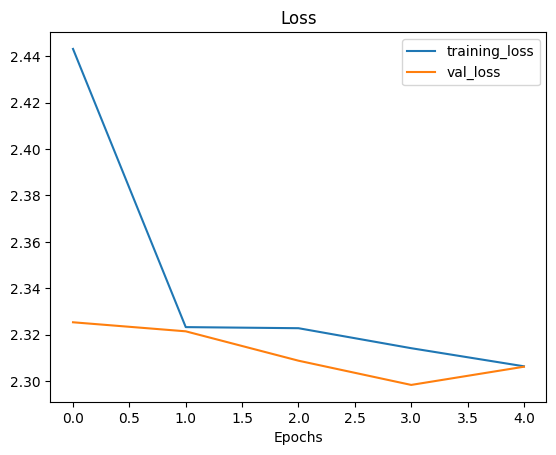

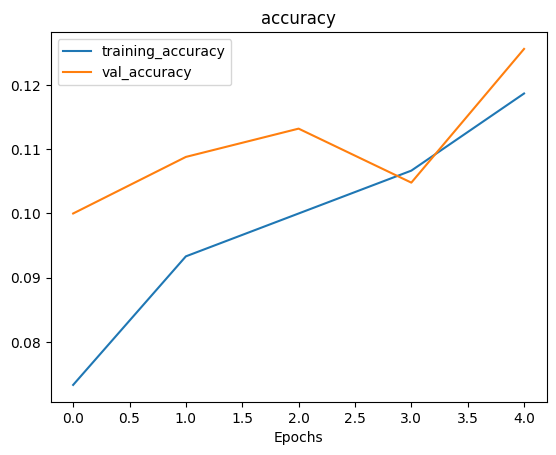

In [27]:
plot_loss_curves(resnet_history)

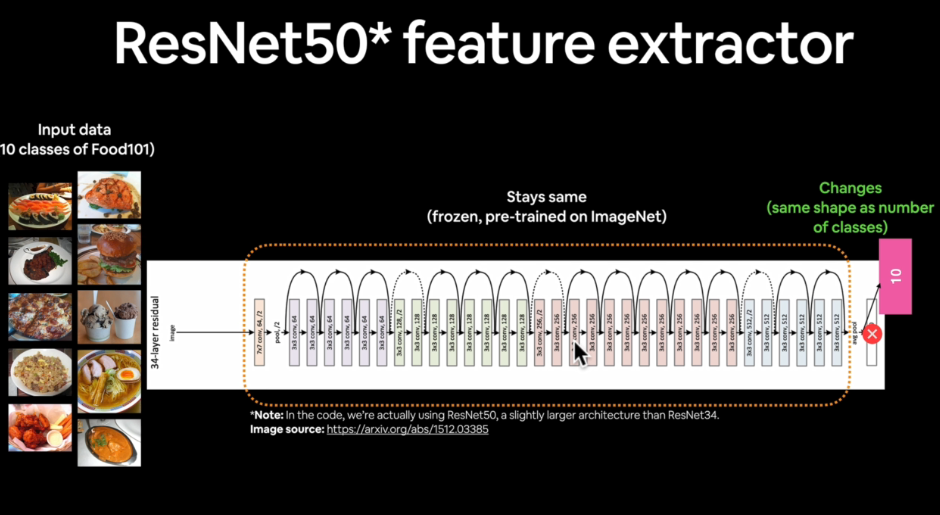

<h1 style="color:red">lec 008:-Building and training a pre-trained EfficientNet model on our data.mp4</h1>

### Creating and testing EfficientNetB0 TensorFlow Hub Feature Extraction model

In [28]:
# Resnet 50 V2 feature vector
resnet_url = "https://tfhub.dev/google/imagenet/resnet_v2_50/feature_vector/4"

# Original: EfficientNetB0 feature vector (version 1)
efficientnet_url = "https://tfhub.dev/tensorflow/efficientnet/b0/feature-vector/1"

# # New: EfficientNetB0 feature vector (version 2)
efficientnet_url = "https://tfhub.dev/google/imagenet/efficientnet_v2_imagenet1k_b0/feature_vector/2"


In [29]:
# Create EfficientNetB0 feature extractor model
efficientnet_model = create_efficientnet_model(train_data.num_classes)

# Compile EfficientNet model
efficientnet_model.compile(loss="categorical_crossentropy",
                           optimizer=tf.keras.optimizers.Adam(),
                           metrics=["accuracy"])

In [30]:
# Fit EfficientNet model to 10% of training data
efficientnet_history = efficientnet_model.fit(train_data,
                                              steps_per_epoch=len(train_data),
                                              epochs=5,
                                              validation_data=test_data,
                                              validation_steps=len(test_data),
                                              callbacks=[create_tensorboard_callback(dir_name="tensorflow_hub",
                                                                                     experiment_name="efficientnetb0")])

Saving TensorBoard log files to: tensorflow_hub/efficientnetb0/20260128-191043
Epoch 1/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 75s 2s/step - accuracy: 0.0924 - loss: 2.7221 - val_accuracy: 0.1000 - val_loss: 2.3149
Epoch 2/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 29s 523ms/step - accuracy: 0.1323 - loss: 2.6836 - val_accuracy: 0.1000 - val_loss: 2.3224
Epoch 3/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 8s 357ms/step - accuracy: 0.0908 - loss: 2.7492 - val_accuracy: 0.1000 - val_loss: 2.3387
Epoch 4/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 8s 340ms/step - accuracy: 0.0785 - loss: 2.7518 - val_accuracy: 0.1000 - val_loss: 2.3329
Epoch 5/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 8s 349ms/step - accuracy: 0.1017 - loss: 2.7454 - val_accuracy: 0.1000 - val_loss: 2.3076


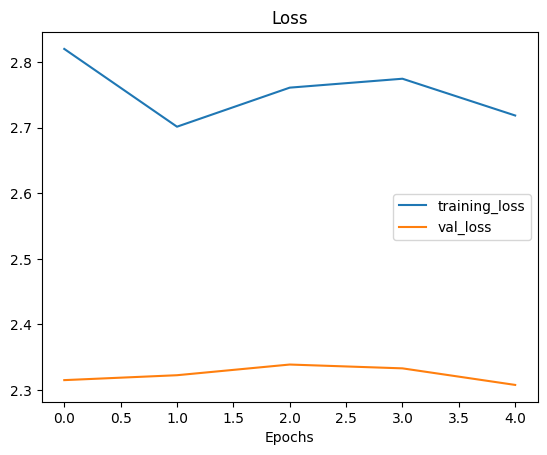

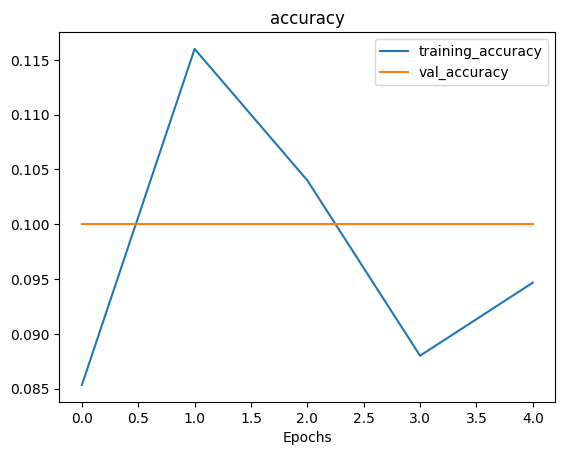

In [31]:
plot_loss_curves(efficientnet_history)

<h1 style="color:red">lec 009:-Different Types of Transfer Learning.mp4</h1>

In [32]:
# How many layers does our efficientnetb0 feature extractor have?
len(efficientnet_model.layers[0].weights)

0

## Different types of transfer learning

* **"As is"** transfer learning - using an existing model with no changes what so ever (e.g. using ImageNet model on 1000 ImageNet classes, none of your own)

* **"Feature extraction"** transfer learning - use the prelearned patterns of an existing model (e.g. EfficientNetB0 trained on ImageNet) and adjust the output layer for your own problem (e.g. 1000 classes -> 10 classes of food)

* **"Fine-tuning"** transfer learning - use the prelearned patterns of an existing model and "fine-tune" many or all of the underlying layers (including new output layers)

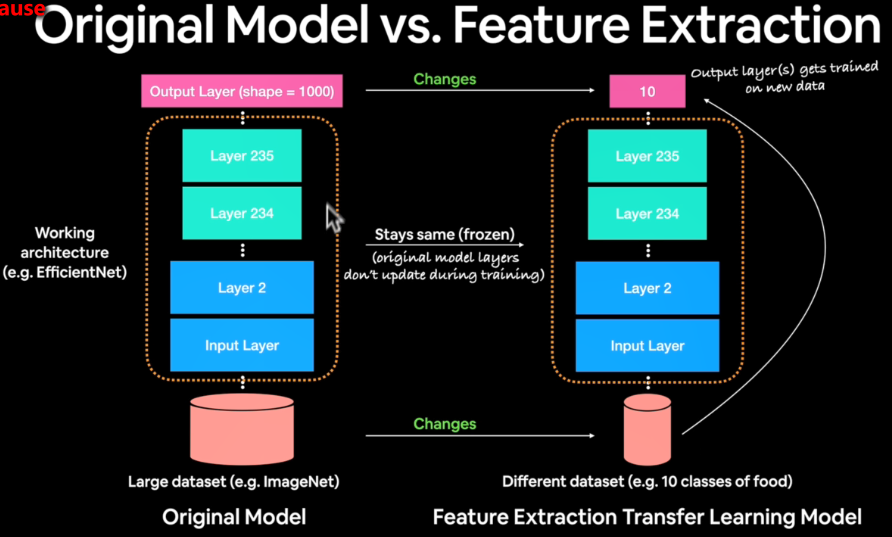

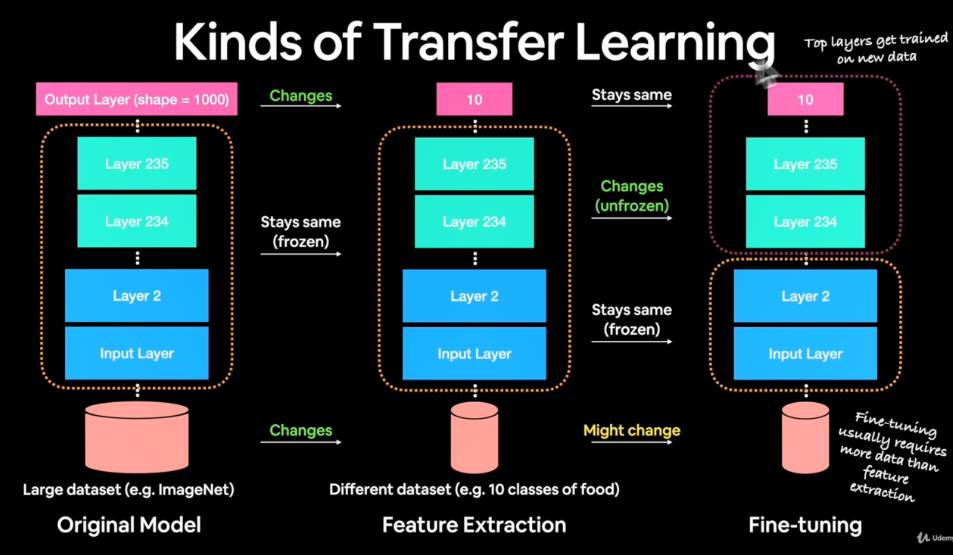

<h1 style="color:red">lec 010:-Comparing Our Model's Results.mp4</h1>

## Comparing our models results using TensorBoard

> 🔑**Note:** When you upload things to TensorBoard.dev, your experiments are public. So if you're running private experiments (things you don't want others to see) do not upload them to TensorBoard.dev

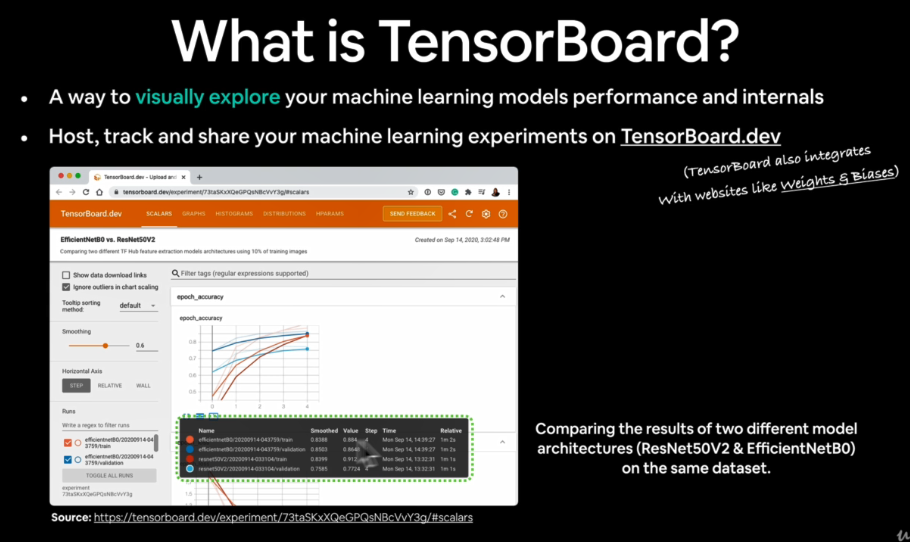

> Note:- use `%tensorboard --logdir logs` tensorboard.dev is closed now
tensorboard guide:- https://www.tensorflow.org/tensorboard/get_started

In [33]:
# Upload TensorBoard dev records
!tensorboard dev upload --logdir ./tensorflow_hub/ \
  --name "EfficientB0 vs. ResNet50V2" \
  --description "Comparing two different TF Hub feature extraction model architectures using 10% of the training data" \
  --one_shot

Our TensorBoard experiments are uploaded publically here:

In [34]:
# Check out what tenserboard experiments you have
!tensorboard dev list

2026-01-28 19:41:12.742126: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1769629272.763115    8395 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1769629272.769632    8395 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1769629272.786825    8395 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769629272.786849    8395 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769629272.786854    8395 computation_placer.cc:177] computation placer alr

<body>
                <div class="container">
                <div class="row">
                <div class="col-md-10 col-md-offset-1">
                    <p class="lead"><p>Holy smokes! We just wiped the floor with all of our previous models' thanks to the power of transfer learning.</p><p>I hope you’re now starting to recognise the power of transfer learning and its advantages over building models from scratch all the time.</p><p>We’re now well on our way to building a state of the art computer vision model for our Food Vision 🍔👁 problem.</p><p>You should now be able to:</p><ul><li><p>Describe the advantages of transfer learning</p></li><li><p>Preprocess image data to be able to be used with a transfer learning model</p></li><li><p>Navigate TensorFlow Hub in search of different pre-trained models for various problem spaces</p></li><li><p>Use a pre-trained TensorFlow Hub computer vision model</p></li></ul><p>Ready to practice?</p><p>In the <a href="https://github.com/mrdbourke/tensorflow-deep-learning" rel="noopener noreferrer" target="_blank">course GitHub repo</a> under “Course materials”, you'll find a series of exercises and extra-curriculum suggestions.</p><p>TensorFlow Hub and the space of pre-trained models is vast. So practising writing more code will help you to identify when you can use a pre-trained model and when you might want to build something from scratch.</p><p>See the link below for more.</p><ul><li><p><a href="https://github.com/mrdbourke/tensorflow-deep-learning/blob/main/README.md#-04-transfer-learning-in-tensorflow-part-1-feature-extraction-exercises" rel="noopener noreferrer" target="_blank">Transfer Learning in TensorFlow Part 1: Feature extraction Exercises &amp; Extra-curriculum</a></p></li></ul><p>And remember, if you have any questions, be sure to <a href="https://github.com/mrdbourke/tensorflow-deep-learning/discussions" rel="noopener noreferrer" target="_blank">add them to the discussions page</a>.</p><p><strong>Challenge:</strong> Create a binary image classification dataset (with 10 images of any two classes, e.g. car vs. truck) and use a pre-trained TensorFlow Hub image classification model to classify them. How does it go?</p><p>Send a message with picture(s) of your results to the #machinelearning-datascience channel on Discord and mention my name (@mrdbourke), I’d love to see them!</p><p>See you in the next module!</p><p>- Daniel</p><p>Web: <a href="http://www.mrdbourke.com/" rel="noopener noreferrer" target="_blank">www.mrdbourke.com</a></p><p>YouTube: <a href="https://dbourke.link/youtube" rel="noopener noreferrer" target="_blank">https://dbourke.link/youtube</a></p></p>
                </div>
                </div>
                </div>
                <script src="https://maxcdn.bootstrapcdn.com/bootstrap/3.3.7/js/bootstrap.min.js" integrity="sha384-Tc5IQib027qvyjSMfHjOMaLkfuWVxZxUPnCJA7l2mCWNIpG9mGCD8wGNIcPD7Txa" crossorigin="anonymous"></script>
                </body>

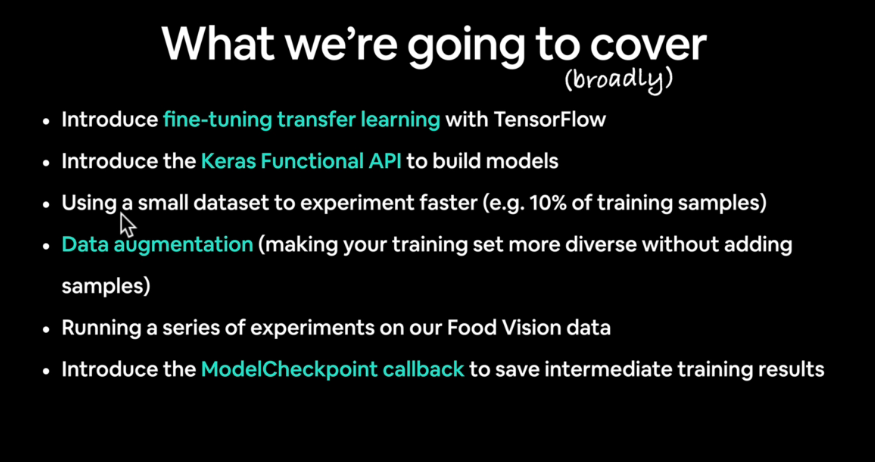